In [1]:
# Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date

## Extract Data Using NOAA Climate Data Online API

In [ ]:
# Fetch API data
url = "https://www.ncei.noaa.gov/cdo-web/api/v2/data"
headers = {"token": "YOUR_TOKEN"}
params = {
    "datasetid": "GHCND",
    "stationid": "GHCND:USW00094789",
    "datatypeid": "PRCP,SNOW,SNWD,TAVG,TMAX,TMIN",
    "startdate": "2026-01-01",
    "enddate": date.today().isoformat(),
    "units": "metric",
    "limit": 1000
}

r = requests.get(url, params=params , headers=headers)
print(r.status_code)

200


In [3]:
# if the status code 200, then parse the data
response_dicts = r.json()
print(response_dicts.keys())
print(response_dicts['metadata'])

response_dict = response_dicts['results']
print(len(response_dict))

dict_keys(['metadata', 'results'])
{'resultset': {'offset': 1, 'count': 1325, 'limit': 1000}}
1000


In [4]:
# Pagination: Fetch second batch of data, due to limit: 1000
params['offset'] = 1001

r2 = requests.get(url, params=params, headers=headers)
print(r2.status_code)

response_dicts_2 = r2.json()
print(response_dicts_2['metadata'])

response_dict_2 = response_dicts_2['results']
print(len(response_dict_2))

200
{'resultset': {'offset': 1001, 'count': 1325, 'limit': 1000}}
325


In [5]:
# Combine both data
response_dict = response_dict + response_dict_2
print(len(response_dict))

1325


## Transform Data

In [7]:
# TRANSFORM DATA
# pandas data frame (df)
df = pd.DataFrame(response_dict)
print(df.head())

                  date datatype            station attributes  value
0  2026-01-01T00:00:00     PRCP  GHCND:USW00094789   ,,1,2400    0.5
1  2026-01-01T00:00:00     SNOW  GHCND:USW00094789       ,,1,   10.0
2  2026-01-01T00:00:00     SNWD  GHCND:USW00094789  T,,1,2400    0.0
3  2026-01-01T00:00:00     TMAX  GHCND:USW00094789   ,,1,2400    2.2
4  2026-01-01T00:00:00     TMIN  GHCND:USW00094789   ,,1,2400   -6.1


In [ ]:
# Inspect
print(df.info())
print(df.shape)
print(df.dtypes)
print(df.columns)
print(df['datatype'].unique())
print(df['datatype'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1325 entries, 0 to 1324
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1325 non-null   str    
 1   datatype    1325 non-null   str    
 2   station     1325 non-null   str    
 3   attributes  1325 non-null   str    
 4   value       1325 non-null   float64
dtypes: float64(1), str(4)
memory usage: 51.9 KB
None
(1325, 5)
date              str
datatype          str
station           str
attributes        str
value         float64
dtype: object
Index(['date', 'datatype', 'station', 'attributes', 'value'], dtype='str')
<StringArray>
['PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN']
Length: 5, dtype: str
datatype
PRCP    266
SNOW    266
TMAX    266
TMIN    266
SNWD    261
Name: count, dtype: int64


In [13]:
# change date data type into datetime
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

datetime64[us]


In [15]:
# Create copy of df to work with
df_clean = df.copy()

# drop the column we don't need
df_clean = df_clean.drop(columns=['station', 'attributes'])

print(df_clean.head())

        date datatype  value
0 2026-01-01     PRCP    0.5
1 2026-01-01     SNOW   10.0
2 2026-01-01     SNWD    0.0
3 2026-01-01     TMAX    2.2
4 2026-01-01     TMIN   -6.1


In [16]:
# pivot from long to wide format
df_clean = df_clean.pivot(
    columns='datatype',
    index='date',
    values='value'
).reset_index()

print(df_clean.head())

datatype       date  PRCP  SNOW  SNWD  TMAX  TMIN
0        2026-01-01   0.5  10.0   0.0   2.2  -6.1
1        2026-01-02   0.0   0.0   0.0  -1.1  -6.1
2        2026-01-03   0.0   0.0   0.0  -1.1  -5.0
3        2026-01-04   0.0   0.0   0.0   2.2  -3.3
4        2026-01-05   0.0   0.0   0.0   2.8  -4.4


## Visualize Data

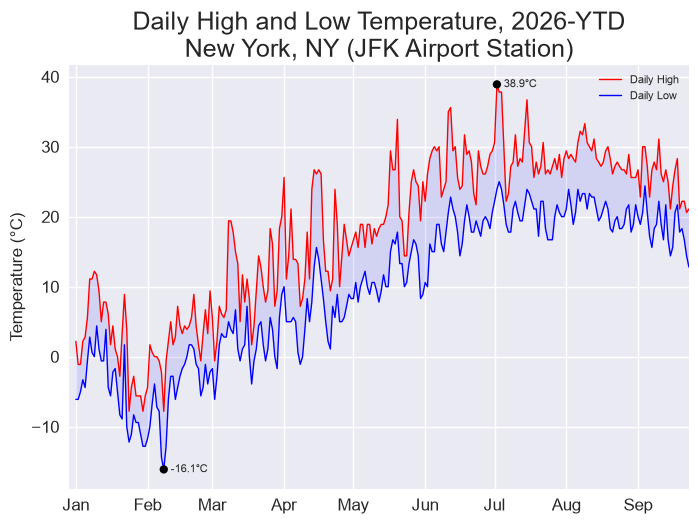

In [17]:

# Daily High vs Low Temperature
plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
ax.plot(df_clean['date'], df_clean['TMAX'], color='red', linewidth=1)
ax.plot(df_clean['date'], df_clean['TMIN'], color='blue', linewidth=1)

ax.fill_between(df_clean['date'], df_clean['TMAX'], df_clean['TMIN'], facecolor='blue', alpha=0.1)

ax.set_title("Daily High and Low Temperature, 2026-YTD\nNew York, NY (JFK Airport Station)", fontsize=18)
ax.set_ylabel("Temperature (\u00b0C)", fontsize=12)
ax.tick_params(labelsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(['Daily High', 'Daily Low'], fontsize=8, loc='upper right')

ax.set_xlim(df_clean['date'].min() - pd.Timedelta(days=3), df_clean['date'].max())

max_temp = df_clean['TMAX'].max()
min_temp = df_clean['TMIN'].min()
max_date = df_clean.loc[df_clean['TMAX'].idxmax(), "date"]
min_date = df_clean.loc[df_clean['TMIN'].idxmin(), "date"]

ax.scatter(x=max_date, y=max_temp, c='black', edgecolors='none', s=36, zorder=3)
ax.scatter(x=min_date, y=min_temp, c='black', edgecolors='none', s=36, zorder=3)

ax.annotate(
    f"{max_temp:.1f}\u00b0C",
    xy=(max_date, max_temp),
    xytext=(5, -2),
    textcoords="offset points",
    fontsize=8
)
ax.annotate(
    f"{min_temp:.1f}\u00b0C",
    xy=(min_date, min_temp),
    xytext=(5, -2),
    textcoords="offset points",
    fontsize=8
)

fig.savefig("charts/tmax_tmin.png", dpi=150)
plt.show()

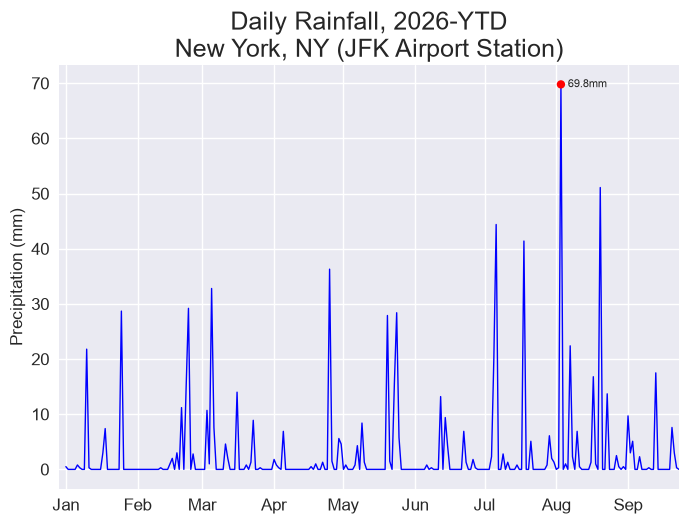

In [18]:

# Daily Rainfall
plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
ax.plot(df_clean['date'], df_clean['PRCP'], color='blue', linewidth=1)

ax.set_title("Daily Rainfall, 2026-YTD\nNew York, NY (JFK Airport Station)", fontsize=18)
ax.set_ylabel("Precipitation (mm)", fontsize=12)
ax.tick_params(labelsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax.set_xlim(df_clean['date'].min() - pd.Timedelta(days=3), df_clean['date'].max())

max_rain = df_clean['PRCP'].max()
max_date = df_clean.loc[df_clean['PRCP'].idxmax(), "date"]
ax.scatter(x=max_date, y=max_rain, c='red', edgecolors='none', s=36, zorder=3)

ax.annotate(
    f"{max_rain:.1f}mm",
    xy=(max_date, max_rain),
    xytext=(5, -2),
    textcoords="offset points",
    fontsize=8
)

fig.savefig("charts/prcp.png", dpi=150)
plt.show()

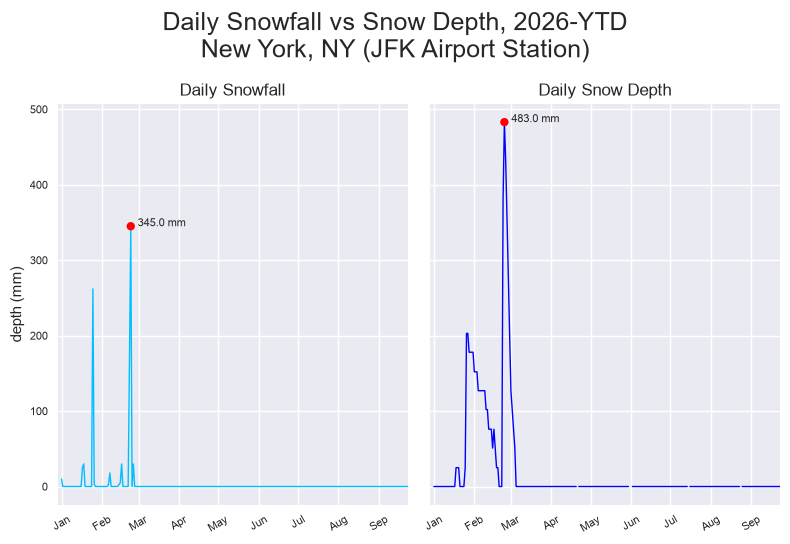

In [19]:

# Daily Snowfall & Snow Depth
plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots(1, 2, sharey=True)

ax[0].plot(df_clean['date'], df_clean['SNOW'], color='deepskyblue', linewidth=1)
ax[1].plot(df_clean['date'], df_clean['SNWD'], color='blue', linewidth=1)

ax[0].set_title("Daily Snowfall")
ax[0].set_ylabel("depth (mm)")

max_snow = df_clean['SNOW'].max()
max_date_snow = df_clean.loc[df_clean['SNOW'].idxmax(), "date"]
ax[0].scatter(x=max_date_snow, y=max_snow, c='red', edgecolors='none', s=36, zorder=3)
ax[0].annotate(f"{max_snow:.1f} mm", xy=(max_date_snow, max_snow), xytext=(5, 0), textcoords="offset points", fontsize=8)

ax[1].set_title("Daily Snow Depth")

max_snwd = df_clean['SNWD'].max()
max_date_snwd = df_clean.loc[df_clean['SNWD'].idxmax(), "date"]
ax[1].scatter(x=max_date_snwd, y=max_snwd, c='red', edgecolors='none', s=36, zorder=3)
ax[1].annotate(f"{max_snwd:.1f} mm", xy=(max_date_snwd, max_snwd), xytext=(5, 0), textcoords="offset points", fontsize=8)

for a in ax:
    a.xaxis.set_major_locator(mdates.MonthLocator())
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    a.set_xlim(df_clean['date'].min() - pd.Timedelta(days=3), df_clean['date'].max())
    a.tick_params(axis='x', rotation=30, labelsize=8)
    a.tick_params(axis='y', labelsize=8)

fig.suptitle("Daily Snowfall vs Snow Depth, 2026-YTD\nNew York, NY (JFK Airport Station)", fontsize=18)
fig.tight_layout()

fig.savefig("charts/snow_snwd.png", dpi=150)
plt.show()